In [1]:
import math
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

## Loading & processing data

In [2]:
# Selecting the brain region
select_region = "Isocortex-1-IT-ET-Glut"

In [3]:
# Loading AnnData object
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/")
expr_path = base_path / "AnnData/" / f"WMB-10Xv3-{select_region}-raw-wmeta.h5ad"
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 121827 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [4]:
# Count the number of cells in each class
class_counts = adata.obs["subclass"].value_counts()
print(class_counts)

subclass
006 L4/5 IT CTX Glut         44121
007 L2/3 IT CTX Glut         41389
004 L6 IT CTX Glut            9627
005 L5 IT CTX Glut            8558
020 L2/3 IT RSP Glut          7203
022 L5 ET CTX Glut            5927
021 L4 RSP-ACA Glut           1452
001 CLA-EPd-CTX Car3 Glut     1156
002 IT EP-CLA Glut            1112
003 L5/6 IT TPE-ENT Glut      1030
009 L2/3 IT PIR-ENTl Glut       99
010 IT AON-TT-DP Glut           73
008 L2/3 IT ENT Glut            23
025 CA2-FC-IG Glut              18
018 L2 IT PPP-APr Glut          16
019 L2/3 IT PPP Glut            12
016 CA1-ProS Glut                5
017 CA3 Glut                     3
011 L2 IT ENT-po Glut            1
014 LA-BLA-BMA-PA Glut           1
024 L5 PPP Glut                  1
Name: count, dtype: int64


In [5]:
# Identify classes with few cells
n_cells_threshold = 100

# Filter out the cells belonging to the identified classes
classes_to_remove = class_counts[class_counts < n_cells_threshold].index.tolist()
adata = adata[~adata.obs["subclass"].isin(classes_to_remove)].copy()

print(f"Classes with less than {n_cells_threshold} cells ({classes_to_remove}) have been removed.")
adata

Classes with less than 100 cells (['009 L2/3 IT PIR-ENTl Glut', '010 IT AON-TT-DP Glut', '008 L2/3 IT ENT Glut', '025 CA2-FC-IG Glut', '018 L2 IT PPP-APr Glut', '019 L2/3 IT PPP Glut', '016 CA1-ProS Glut', '017 CA3 Glut', '011 L2 IT ENT-po Glut', '014 LA-BLA-BMA-PA Glut', '024 L5 PPP Glut']) have been removed.


AnnData object with n_obs × n_vars = 121575 × 32285
    obs: 'cell_barcode', 'barcoded_cell_sample_label', 'library_label', 'feature_matrix_label', 'entity', 'brain_section_label', 'library_method', 'region_of_interest_acronym', 'donor_label', 'donor_genotype', 'donor_sex', 'dataset_label', 'x', 'y', 'cluster_alias', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color', 'region_of_interest_order', 'region_of_interest_color'
    var: 'gene_symbol'

In [13]:
gene_names_df = adata.var.copy()
adata.var.set_index("gene_symbol", inplace=True)

In [14]:
# Updated Plot function to include Legends
from matplotlib.lines import Line2D
def plot_umap(xx, yy, cc=None, val=None, label_column=None, fig_width=6, fig_height=6, cmap=None):
    # Initialize plot with constrained layout to prevent overlap
    fig, ax = plt.subplots(constrained_layout=True)
    fig.set_size_inches(fig_width, fig_height)
    
    # Plot the data
    if cmap is not None:
        scatter = ax.scatter(xx, yy, s=0.4, c=val, marker='.', cmap=cmap)
    elif cc is not None:
        scatter = ax.scatter(xx, yy, s=0.4, color=cc, marker='.')
    else:
        scatter = ax.scatter(xx, yy, s=0.4, marker='.')
    
    # Set axis properties
    ax.axis('equal')
    # ax.set_xlim(-18, 27)
    # ax.set_ylim(-18, 27)
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add legend if label_column is provided
    if label_column is not None:
        # Create DataFrame for unique label-color pairs
        df_legend = pd.DataFrame({'label': label_column, 'color': cc}).drop_duplicates().sort_values('label')
        
        # Create legend handles
        legend_elements = [
            Line2D([0], [0], 
                   marker='o', 
                   color='w', 
                   label=row['label'],
                   markerfacecolor=row['color'], 
                   markersize=8)
            for _, row in df_legend.iterrows()
        ]
        
        # Add legend outside the plot (adjust bbox_to_anchor as needed)
        ax.legend(
            handles=legend_elements, 
            title="Legend", 
            loc="upper left",  # Anchor point for the legend
            bbox_to_anchor=(1.05, 1)  # Shift legend to the right of the plot
        )
    
    return fig, ax

In [15]:
cell_subsampled = adata.obs
print(len(cell_subsampled))

121575


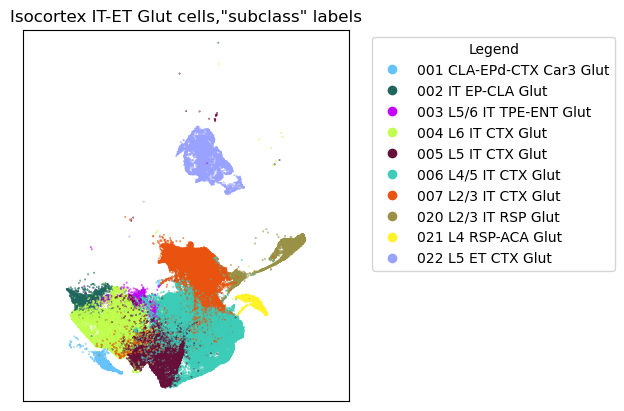

In [16]:
fig, ax = plot_umap(
    cell_subsampled['x'],
    cell_subsampled['y'],
    label_column = cell_subsampled['subclass'],
    cc = cell_subsampled['subclass_color'],
    fig_width=6,
    fig_height=4
    )
res = ax.set_title("Isocortex IT-ET Glut cells,\"subclass\" labels")
plt.show()

In [17]:
# Preprocess the data
sc.pp.normalize_total(adata, target_sum=1e4)  # Normalize counts per cell
sc.pp.log1p(adata)  # Log-transform the data
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=True)  # Select highly variable genes

### DE

In [18]:
# Perform differential expression analysis
group_by="subclass"
sc.tl.rank_genes_groups(
    adata,
    groupby=group_by,
    method="wilcoxon",
    use_raw=False
)

In [19]:
# Extract the differential expression results
deg_results = pd.DataFrame({
    group: pd.DataFrame(adata.uns["rank_genes_groups"]["names"])[group]
    for group in adata.uns["rank_genes_groups"]["names"].dtype.names
})

# Save the dataframe to a CSV file
output_path = base_path / "outputs/DEG/" / f"WMB-10Xv3-{select_region}-DEG-{group_by}.csv"
deg_results.to_csv(output_path, index=False)

print(f"Differentially expressed genes saved to {output_path}")

Differentially expressed genes saved to /data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs/DEG/WMB-10Xv3-Isocortex-1-IT-ET-Glut-DEG-subclass.csv


In [20]:
deg_results.head()

,001 CLA-EPd-CTX Car3 Glut,002 IT EP-CLA Glut,003 L5/6 IT TPE-ENT Glut,004 L6 IT CTX Glut,005 L5 IT CTX Glut,006 L4/5 IT CTX Glut,007 L2/3 IT CTX Glut,020 L2/3 IT RSP Glut,021 L4 RSP-ACA Glut,022 L5 ET CTX Glut
0,Synpr,Sulf1,Fxyd6,Cdh9,Il1rapl2,Rorb,Rasgrf2,Tshz2,Cbln1,Bcl11b
1,Nr4a2,Nnat,Cnr1,Sema3e,Sulf2,Kcnk2,Rgs6,Slc17a6,Parm1,Fezf2
2,Rgs12,Chst11,C1ql3,Bmp3,Tmsb10,Nrsn1,Calb1,Zfpm2,Nrip3,Parm1
3,Gnb4,Nfia,Timp2,Igsf21,Deptor,Cnih3,Gsg1l,Htr2c,Ntng1,Hcn1
4,B3gat2,Tenm3,Gap43,Galnt14,Grik3,Kcnh5,Dgkb,Unc13c,Ccdc136,Rab3c


## Visualization
https://scanpy.readthedocs.io/en/stable/tutorials/plotting/core.html

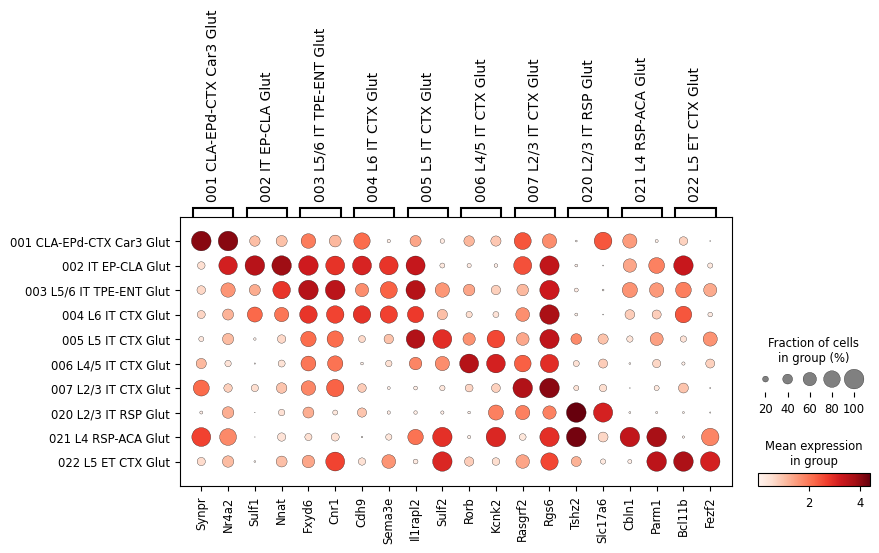

In [23]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=2, dendrogram=False)

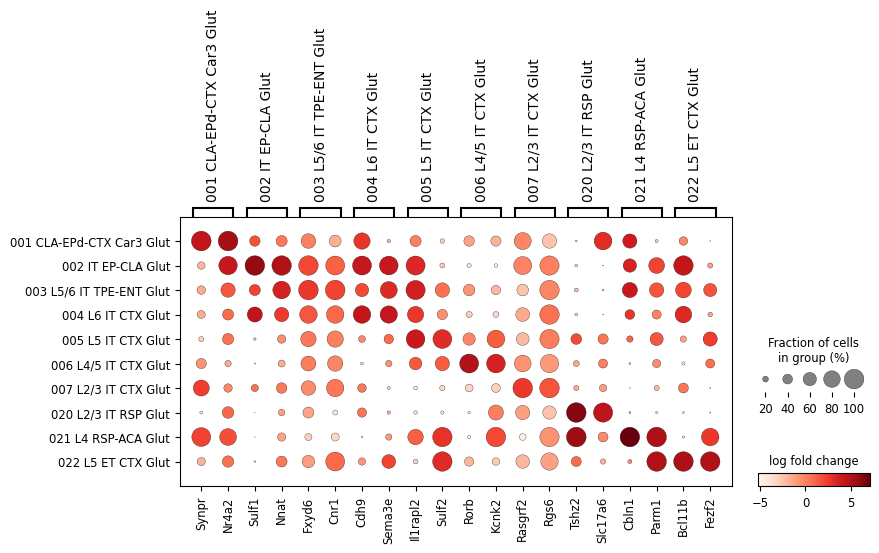

In [24]:
sc.pl.rank_genes_groups_dotplot(adata, n_genes=2, values_to_plot="logfoldchanges", dendrogram=False)

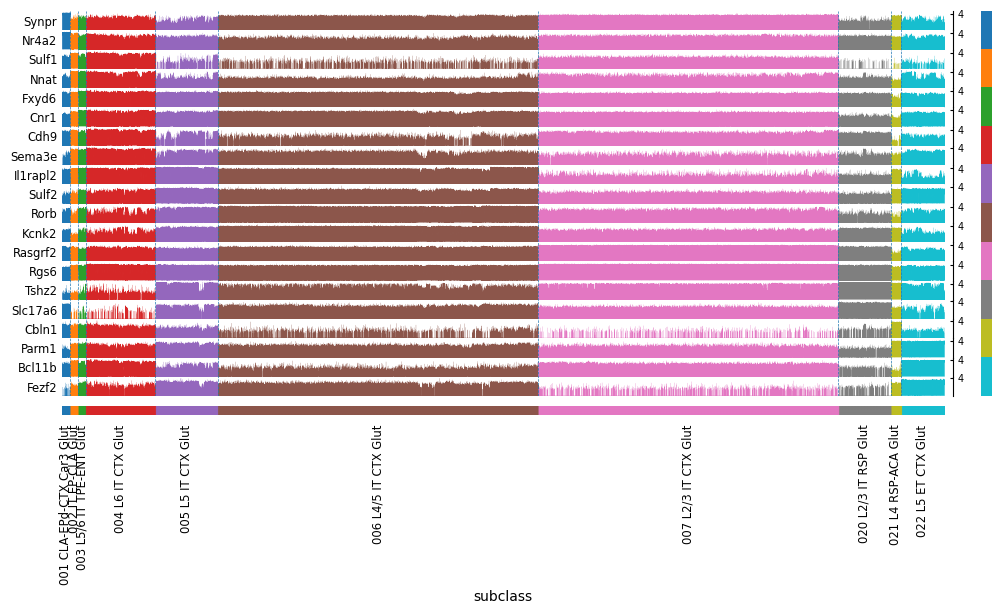

In [25]:
sc.pl.rank_genes_groups_tracksplot(adata, n_genes=2, dendrogram=False)

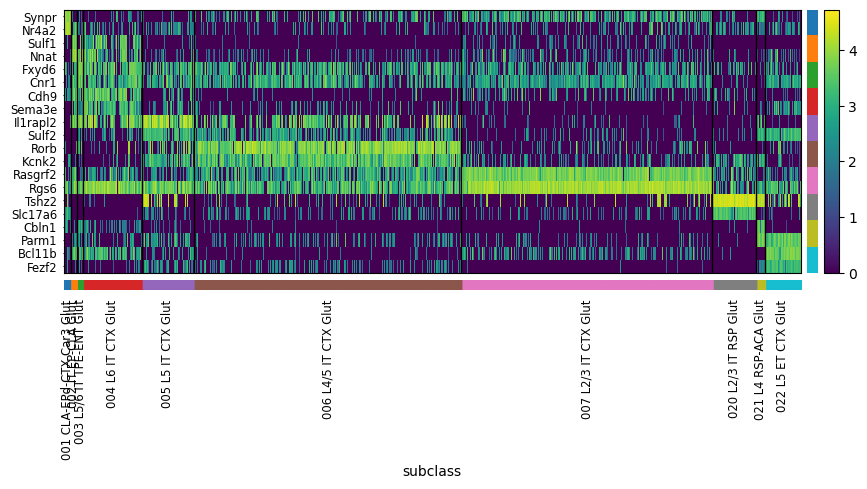

In [26]:
sc.pl.rank_genes_groups_heatmap(adata, n_genes=2, dendrogram=False, swap_axes=True)

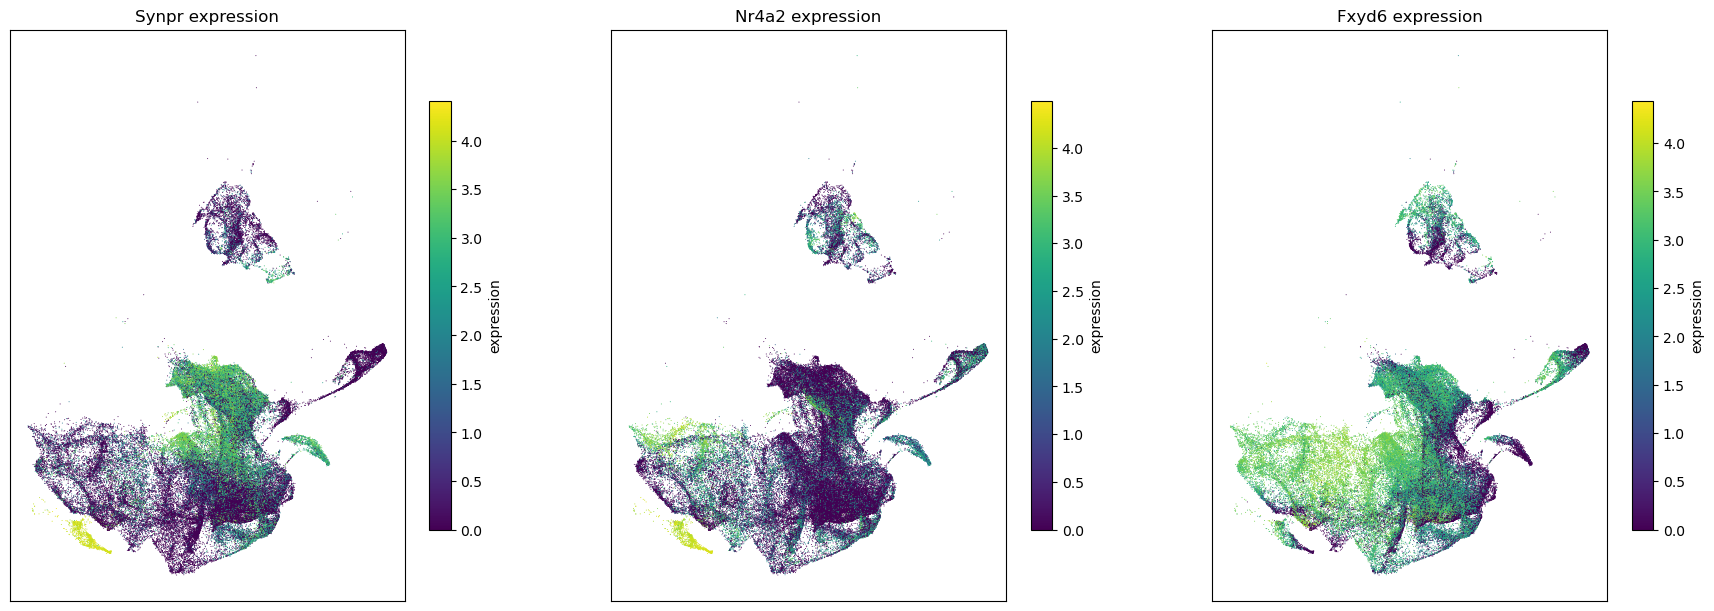

In [ ]:
# Selecting genes to plot
top_genes = ["Synpr", "Nr4a2", "Fxyd6"] # Sema3e

# Create a figure with subplots
fig, axes = plt.subplots(1, len(top_genes), figsize=(6 * len(top_genes), 6), constrained_layout=True)

# If there's only one gene, make sure axes is iterable
if len(top_genes) == 1:
    axes = [axes]

# Plot the expression of each gene using UMAP coordinates from adata.obs
for ax, gene in zip(axes, top_genes):
    scatter = ax.scatter(
        adata.obs["x"],
        adata.obs["y"],
        c=adata[:, gene].X.toarray().flatten(),
        cmap="viridis",
        s=0.5,
        edgecolor="none"
    )
    fig.colorbar(scatter, ax=ax, shrink = 0.75, label=f"expression")
    # if gene in ["Laptm5", "Cst3"]:
    #     ax.set_title(f"{gene} expression (Immune marker)")
    # elif gene in ["Qk", "Olig1"]:
    #     ax.set_title(f"{gene} expression (OPC-Oligo marker)")
    ax.set_title(f"{gene} expression")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.show()

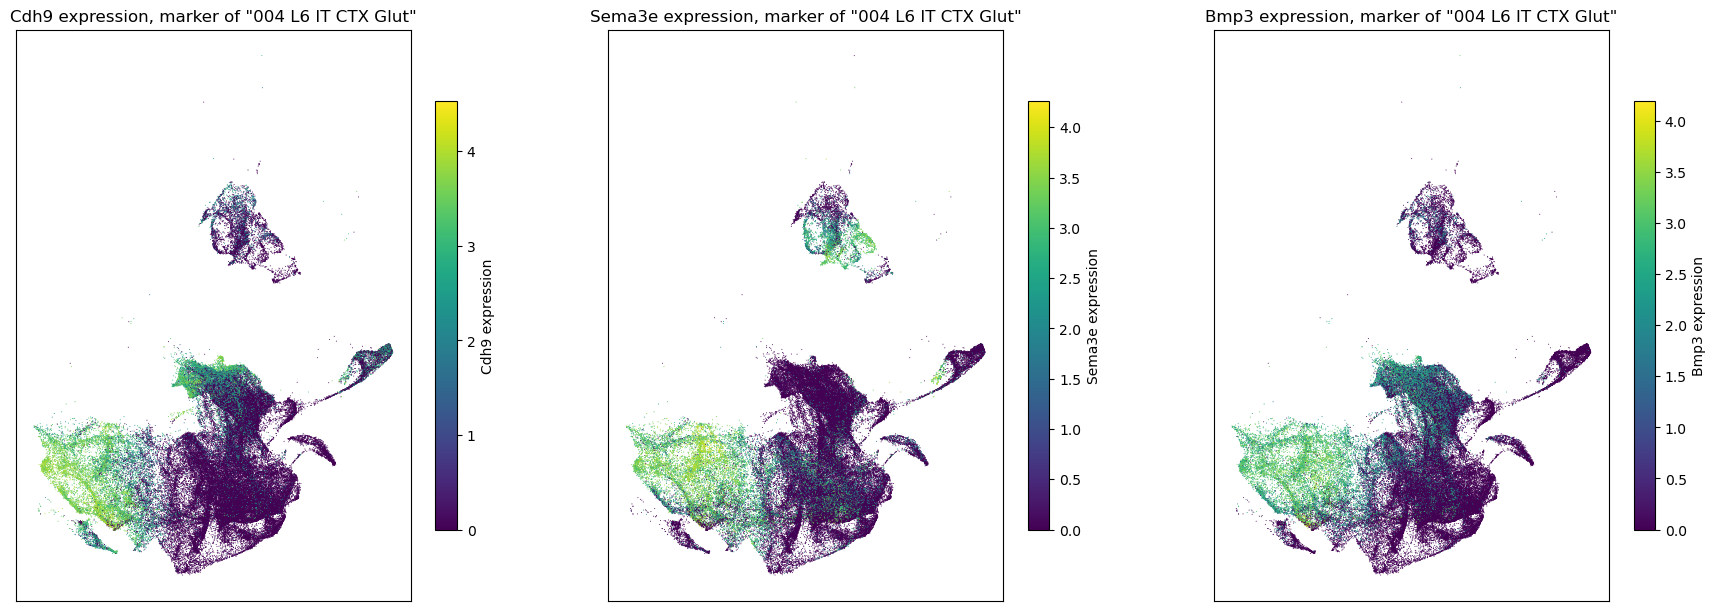

In [35]:
# Select a group and get the top genes
group = "004 L6 IT CTX Glut"
top_genes = deg_results[group].head(3)

# Create a figure with subplots
fig, axes = plt.subplots(1, len(top_genes), figsize=(6 * len(top_genes), 6), constrained_layout=True)

# If there's only one gene, make sure axes is iterable
if len(top_genes) == 1:
    axes = [axes]

# Plot the expression of each gene using UMAP coordinates from adata.obs
for ax, gene in zip(axes, top_genes):
    scatter = ax.scatter(
        adata.obs["x"],
        adata.obs["y"],
        c=adata[:, gene].X.toarray().flatten(),
        cmap="viridis",
        s=0.5,
        edgecolor="none"
    )
    fig.colorbar(scatter, ax=ax, shrink = 0.75, label=f"{gene} expression")
    ax.set_title(f"{gene} expression, marker of \"{group}\"")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.show()

### Specificity

In [36]:
# Compute Tau scores
def compute_tau_score(adata, cluster_name, n_genes, group_by="class"):
    
    # Get expression matrix for the given cluster
    deg_expression_matrix = pd.DataFrame(
    adata.X.toarray(),  # Convert sparse matrix to dense
    index=adata.obs[group_by],  # Use the group_by column as the index
    columns=adata.var.index  # Use gene names as columns
    )

    # Select the top genes for the given cluster
    top_genes = deg_results[cluster_name].head(n_genes)

    # Compute Tau score for each gene
    tau_scores = {}
    for gene in top_genes:
        expression_values = deg_expression_matrix[gene]
        max_expression = expression_values.max()
        if max_expression > 0:
            normalized_expression = 1 - (expression_values / max_expression)
            tau_score = normalized_expression.sum() / (len(expression_values) - 1)
            tau_scores[gene] = tau_score
        else:
            tau_scores[gene] = 0

    # Convert to DataFrame
    tau_scores_df = pd.DataFrame(list(tau_scores.items()), columns=["Gene", "Tau Score"])
    return tau_scores_df

# Prompt for cluster name and number of genes
cluster_name = "004 L6 IT CTX Glut"
n_genes = 3

# Compute Tau scores
tau_scores_df = compute_tau_score(adata, cluster_name, n_genes)
print(tau_scores_df)

     Gene  Tau Score
0    Cdh9   0.829561
1  Sema3e   0.838887
2    Bmp3   0.816891


## Validation

### Biological relevance: GO enrichment analysis

In [37]:
from gprofiler import GProfiler

# Parameters
n_top_genes = 50  # Number of top DEGs to include per cluster
organism = "mmusculus"  # Mouse gene symbols (use "hsapiens" for human)

# Initialize g:Profiler client
gp = GProfiler(return_dataframe=True)

# Store all results
go_enrichment_results = []

# Loop through each cluster in the DEG results
for cluster in deg_results.columns:
    # Get the top n DEGs for the cluster
    top_genes = deg_results[cluster].dropna().head(n_top_genes).tolist()
    
    # Skip clusters with no DEGs
    if not top_genes:
        print(f"Skipping {cluster}: no DEGs found.")
        continue
    
    # Perform GO enrichment analysis
    enrichment_result = gp.profile(
        organism=organism,
        query=top_genes,
        sources=["GO:BP"]  # Biological Process, Molecular Function, Cellular Component, "GO:MF", "GO:CC"
    )
    
    # Add cluster name to the results
    enrichment_result["cluster"] = cluster
    go_enrichment_results.append(enrichment_result)

# Combine all results into a single DataFrame
go_results_df = pd.concat(go_enrichment_results, ignore_index=True)

# Display the first few rows of the results
go_results_df.head()

/tmp/ipykernel_1873429/1006927530.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  go_results_df = pd.concat(go_enrichment_results, ignore_index=True)


,source,native,name,p_value,significant,description,term_size,query_size,intersection_size,effective_domain_size,precision,recall,query,parents,cluster
0,GO:BP,GO:0023052,signaling,0.019458,True,"""The entirety of a process in which informatio...",7507,46,27,26963,0.586957,0.003597,query_1,[GO:0050789],001 CLA-EPd-CTX Car3 Glut
1,GO:BP,GO:0007399,nervous system development,0.019557,True,"""The process whose specific outcome is the pro...",2531,46,15,26963,0.326087,0.005927,query_1,[GO:0048731],001 CLA-EPd-CTX Car3 Glut
2,GO:BP,GO:0022008,neurogenesis,0.020452,True,"""Generation of cells within the nervous system...",1907,46,13,26963,0.282609,0.006817,query_1,"[GO:0007399, GO:0030154]",001 CLA-EPd-CTX Car3 Glut
3,GO:BP,GO:0007154,cell communication,0.021142,True,"""Any process that mediates interactions betwee...",7538,46,27,26963,0.586957,0.003582,query_1,[GO:0009987],001 CLA-EPd-CTX Car3 Glut
4,GO:BP,GO:0048731,system development,0.033340,True,"""The process whose specific outcome is the pro...",4123,46,19,26963,0.413043,0.004608,query_1,"[GO:0007275, GO:0048856]",001 CLA-EPd-CTX Car3 Glut


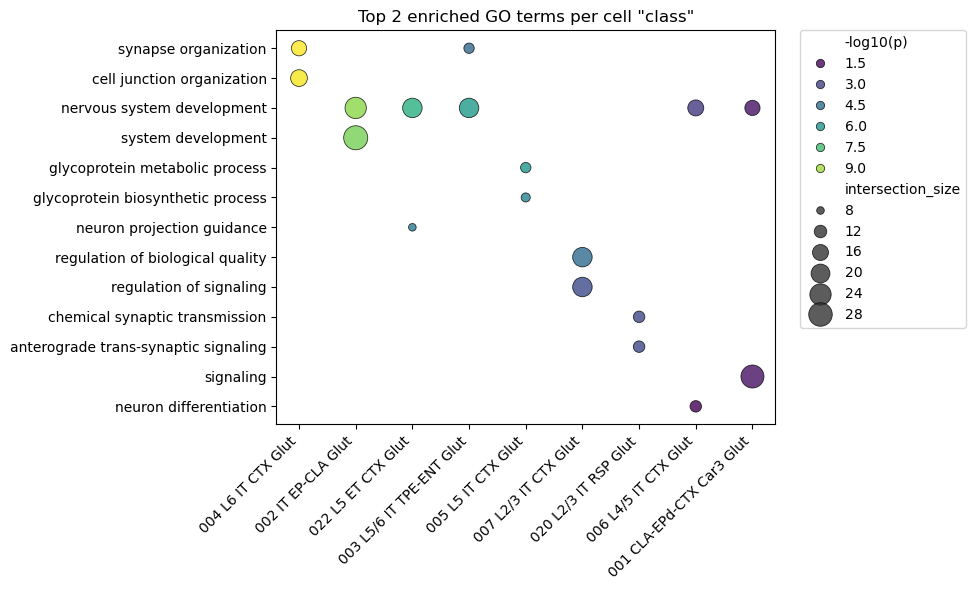

In [38]:
# ---------------------------------------------
# Parameters
# ---------------------------------------------
top_n = 2  # Top terms per cluster to include

# ---------------------------------------------
# Select top N enriched terms per cluster
# ---------------------------------------------
top_terms_df = (
    go_results_df
    .sort_values("p_value")
    .groupby("cluster")
    .head(top_n)
    .copy()
)

# Shorten term names for better plotting
top_terms_df["term_display"] = top_terms_df["name"].str.slice(0, 50)
top_terms_df["-log10(p)"] = -np.log10(top_terms_df["p_value"] + 1e-300)

# Optional: sort GO terms by frequency of appearance across clusters
term_order = (
    top_terms_df["term_display"]
    .value_counts()
    .index.tolist()
)

# ---------------------------------------------
# Create the Dot Plot
# ---------------------------------------------
plt.figure(figsize=(10, max(6, 0.4 * len(term_order))))
sns.scatterplot(
    data=top_terms_df,
    x="cluster",
    y="term_display",
    size="intersection_size",
    hue="-log10(p)",
    sizes=(30, 300),
    palette="viridis",
    edgecolor="black",
    alpha=0.8,
)

# Improve layout
plt.xticks(rotation=45, ha="right")
plt.ylabel("") # "GO term"
plt.xlabel("") # "Cell class"
plt.title(f"Top {top_n} enriched GO terms per cell \"class\"")

# Legends
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout()
plt.show()

### Statistical robustness: permutation test via label shuffling

* Shuffle the "class" labels in .obs
* Run DE analysis on the shuffled labels
* Collect top DE genes or statistics (e.g., adjusted p-values or log fold changes)
* Repeat this process multiple times (e.g., 100–1000 permutations)
* Compare your real DEGs to this null distribution to assess how likely they are to arise by chance

In [9]:
from joblib import Parallel, delayed

group_by  = "class"          # same as you used for the original DE call
method    = "wilcoxon"       # or 't-test_overestim_var', etc.
n_perms   = 100              # 1 000 is OK; >5 000 gives smoother tails
n_jobs    = -1               # how many CPU cores to use (‑1 == all)

In [10]:
# ------------------------------------------------------------------
# 1.  Run the observed DE test once                             
# ------------------------------------------------------------------
sc.tl.rank_genes_groups(adata, groupby=group_by, method=method, use_raw=False)

# Capture the observed statistics in a convenient dictionary
def _collect_scores(ad):
    res = {}
    names  = ad.uns["rank_genes_groups"]["names"]
    scores = ad.uns["rank_genes_groups"]["scores"]  # test statistic
    for clust in names.dtype.names:
        for g, s in zip(names[clust], scores[clust]):
            res[(clust, g)] = s
    return res

observed_scores = _collect_scores(adata)

In [11]:
# ------------------------------------------------------------------
# 2.  Single‑permutation helper  (runs in parallel)               
# ------------------------------------------------------------------
def _permute_and_score(ad, seed=None):
    """Shuffle the labels and return a dict { (cluster, gene): score }."""
    rng  = np.random.default_rng(seed)
    ad_p = ad.copy()
    ad_p.obs[group_by] = rng.permutation(ad_p.obs[group_by].values)
    sc.tl.rank_genes_groups(ad_p, groupby=group_by, method=method, use_raw=False)
    return _collect_scores(ad_p)

In [12]:
# ------------------------------------------------------------------
# 3.  Run the permutation test                                   
# ------------------------------------------------------------------
perm_dicts = Parallel(n_jobs=n_jobs, verbose=10)(
                delayed(_permute_and_score)(adata, seed)
                for seed in range(n_perms)
             )

# Bring the permutation scores into a single DataFrame
perm_df = (pd.DataFrame(perm_dicts)          # columns = permutations
             .T                              # rows   = (cluster, gene)
             .fillna(0.0)                    # gene may drop out of top‑N
)
perm_df.index = pd.MultiIndex.from_tuples(perm_df.index,
                                          names=["cluster", "gene"])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 56 concurrent workers.
[Parallel(n_jobs=-1)]: Done  11 out of 100 | elapsed:  2.2min remaining: 17.4min
[Parallel(n_jobs=-1)]: Done  22 out of 100 | elapsed:  2.2min remaining:  7.8min
[Parallel(n_jobs=-1)]: Done  33 out of 100 | elapsed:  2.3min remaining:  4.6min
[Parallel(n_jobs=-1)]: Done  44 out of 100 | elapsed:  2.3min remaining:  2.9min
[Parallel(n_jobs=-1)]: Done  55 out of 100 | elapsed:  2.3min remaining:  1.9min
[Parallel(n_jobs=-1)]: Done  66 out of 100 | elapsed:  3.9min remaining:  2.0min
[Parallel(n_jobs=-1)]: Done  77 out of 100 | elapsed:  3.9min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  88 out of 100 | elapsed:  4.0min remaining:   32.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  4.0min finished


In [ ]:
# ------------------------------------------------------------------
# 4.  Empirical p‑values  (1‑sided: permutation score ≥ observed) 
# ------------------------------------------------------------------
p_vals = {}
for key, obs_s in observed_scores.items():
    perm_s = perm_df.loc[key].values           # vector length = n_perms
    p_vals[key] = (np.sum(perm_s >= obs_s) + 1) / (n_perms + 1)

# --- patch: create a MultiIndex with level names ------------------
pval_s = pd.Series(p_vals)
pval_s.index = pd.MultiIndex.from_tuples(pval_s.index,
                                         names=["cluster", "gene"])

# genes × clusters DataFrame
pval_df = (pval_s
             .unstack(level="cluster")         # or: .unstack(0)
             .sort_index()
)

# Optional: Benjamini–Hochberg FDR across all tests
from statsmodels.stats.multitest import multipletests
flat_p   = pval_df.stack().values
fdr_adj  = multipletests(flat_p, method="fdr_bh")[1]
fdr_df   = pd.Series(fdr_adj,
                     index=pval_df.stack().index).unstack(level="cluster")

# Save for downstream use
# pval_df.to_csv("DEG_permutation_empirical_pvals.csv")
# fdr_df.to_csv("DEG_permutation_FDR.csv")

In [31]:
# -----------------------------------------------
# Choose the cluster you're interested in
# -----------------------------------------------
cluster = "34 Immune"    # <- change this to your target cluster name

# -----------------------------------------------
# Extract Scanpy DE results for that cluster
# -----------------------------------------------
# Convert the rank_genes_groups result to a DataFrame
de_result = pd.DataFrame({
    "gene": adata.uns["rank_genes_groups"]["names"][cluster],
    "score": adata.uns["rank_genes_groups"]["scores"][cluster],
    "logfoldchanges": adata.uns["rank_genes_groups"]["logfoldchanges"][cluster],
    "pval": adata.uns["rank_genes_groups"]["pvals"][cluster],
    "pval_adj": adata.uns["rank_genes_groups"]["pvals_adj"][cluster]
})

# -----------------------------------------------
# Add the empirical p-values from the permutation test
# -----------------------------------------------
# Join using gene name as index
de_result["empirical_pval"] = pval_df[cluster].reindex(de_result["gene"].values).values

# Sort by test statistic (descending), matching Scanpy's order
de_result_sorted = de_result.sort_values("score", ascending=False)

# Optional: view top DEGs by score
de_result_sorted.head(10)

,gene,score,logfoldchanges,pval,pval_adj,empirical_pval
0,Laptm5,102.325294,11.670257,0.0,0.0,0.009901
1,Inpp5d,101.471146,9.586122,0.0,0.0,0.009901
2,Cst3,100.360229,6.652828,0.0,0.0,0.009901
3,Serinc3,99.846977,4.060781,0.0,0.0,0.009901
4,Csf1r,99.571075,11.067130,0.0,0.0,0.009901
5,Zfhx3,99.061943,7.044516,0.0,0.0,0.009901
6,Lyn,98.561783,6.245395,0.0,0.0,0.009901
7,C1qa,98.362793,11.615284,0.0,0.0,0.009901
8,Tyrobp,98.218712,11.134317,0.0,0.0,0.009901
9,C1qc,98.145554,11.758708,0.0,0.0,0.009901


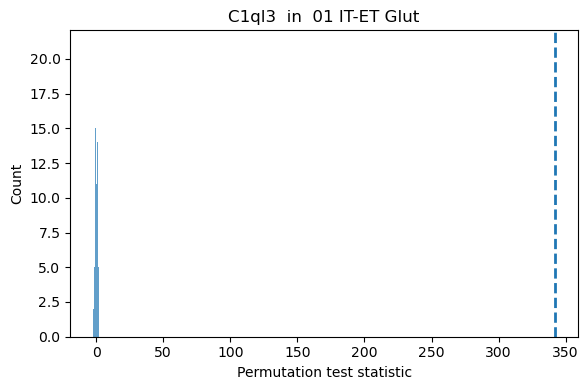

In [32]:
# ------------------------------------------------------------------
# 5.  Visualisation                                              
# ------------------------------------------------------------------
## 5a. Distribution check for a single (cluster, gene) ------------
example_cluster = list(observed_scores.keys())[0][0]   # pick the first cluster
example_gene    = list(observed_scores.keys())[0][1]   # and first gene

perm_scores = perm_df.loc[(example_cluster, example_gene)].values
obs_score   = observed_scores[(example_cluster, example_gene)]

plt.figure(figsize=(6,4))
plt.hist(perm_scores, bins=10, alpha=0.7)
plt.axvline(obs_score, ls="--", lw=2)
plt.xlabel("Permutation test statistic")
plt.ylabel("Count")
plt.title(f"{example_gene}  in  {example_cluster}")
plt.tight_layout()
plt.show()

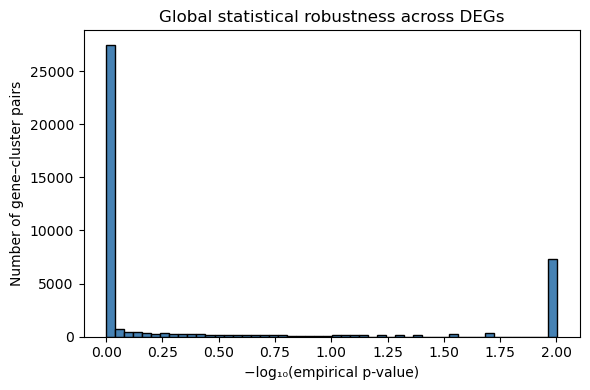

In [ ]:
# Histogram of all permutation p-values (−log10)
all_pvals = pval_df.values.flatten()
all_pvals = all_pvals[~np.isnan(all_pvals)]     # Remove NaNs if any

plt.figure(figsize=(6, 4))
plt.hist(-np.log10(all_pvals + 1e-300), bins=50, color="steelblue", edgecolor="k")
plt.xlabel("−log₁₀(empirical p-value)")
plt.ylabel("Number of gene–cluster pairs")
plt.title("Global statistical robustness across DEGs")
plt.tight_layout()
plt.show()